## Interpretación y análisis de errores 
Para entender el impacto real de los errores de un algoritmo de clasificación, no podemos ver los datos solo como números en una matriz; debemos analizar las consecuencias humanas y clínicas de los errores del modelo. 

Tomando como ejemplo un sistema de Machine Learning diseñado para diagnosticar si un paciente tiene o no una **enfermedad cardíaca**, explicamos los dos tipos de errores posibles:

### 1. Falso Positivo (FP) - Error Tipo I
* **¿Qué significa en este contexto?:** Ocurre cuando el modelo **predice que el paciente TIENE una enfermedad cardíaca**, pero en la realidad el paciente está **completamente sano**.
* **Impacto clínico y psicológico:** Aunque es un error, el impacto es principalmente logístico y emocional. Al paciente se le dará un gran susto (estrés psicológico) y el cardiólogo ordenará exámenes médicos adicionales y más costosos (como un ecocardiograma o un cateterismo) para confirmar el diagnóstico. Eventualmente, en las pruebas secundarias, se descubrirá que el corazón está bien. El costo es económico y de tiempo, pero la vida del paciente no corre peligro inmediato por el error.

### 2. Falsos Negativos (FN) - Error Tipo II
* **¿Qué significa en este contexto?:** Ocurre cuando el modelo **predice que el paciente está SANO**, pero en la realidad el paciente **SÍ TIENE una enfermedad cardíaca grave**.
* **Impacto clínico y psicológico:** Este es el **error más peligroso y crítico** en medicina. Como el algoritmo dice que el paciente está "sano", el médico lo manda a la casa sin tratamiento y sin cuidados. El paciente se confía, la enfermedad cardíaca sigue evolucionando sin control y puede terminar en un desenlace fatal, como un infarto agudo de miocardio en los próximos días. Aquí el costo del error del modelo puede ser la vida de una persona.

### Conclusión para el diseño del modelo:
En Ciencia de Datos aplicada a la salud, casi siempre buscamos optimizar el **Recall (Sensibilidad)** por encima de la Precisión. Preferimos configurar el árbol de decisión para que cometa algunos Falsos Positivos (asustar a alguien sano por precaución), con tal de reducir los Falsos Negativos a cero (no dejar ir a ningún enfermo a casa).

Matriz de confusión:
 [[32 12]
 [12 35]]

Reporte de métricas:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73        44
           1       0.74      0.74      0.74        47

    accuracy                           0.74        91
   macro avg       0.74      0.74      0.74        91
weighted avg       0.74      0.74      0.74        91



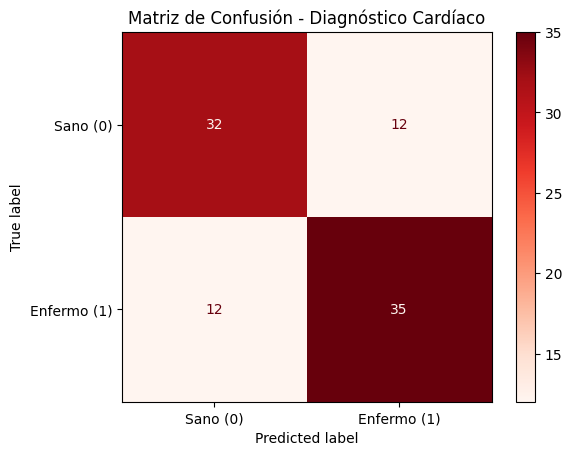

In [7]:
# ==============================================================================
# 1. CARGA AUTOMÁTICA DEL DATASET (KAGGLE / HEART.CSV)
# ==============================================================================
import pandas as pd

# Descargamos el archivo CSV directamente desde un repositorio fuente confiable
url = "https://raw.githubusercontent.com/ammardab3an/Heart-Disease-Prediction/main/heart.csv"
df = pd.read_csv('heart.csv')

# Separamos las características (X) quitando la columna objetivo 'target'
# 'target' indica: 0 = Sano, 1 = Enfermedad Cardíaca
X = df.drop(columns=['target'])
y = df['target']

# ==============================================================================
# 2. CÓDIGO BASE DEL AUTÓNOMO: DIVISIÓN, ENTRENAMIENTO Y EVALUACIÓN
# ==============================================================================
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# División de datos en entrenamiento (70%) y prueba (30%)
# random_state=0 asegura que la división de los pacientes sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0) 

# Entrenar árbol de decisión con una profundidad máxima de 5 para controlar el sobreajuste
clf = DecisionTreeClassifier(max_depth=5, random_state=0)
clf.fit(X_train, y_train) 

# Evaluación del modelo utilizando el conjunto de prueba (datos que el árbol nunca vio)
y_pred = clf.predict(X_test) 

# Mostrar resultados en consola
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred)) 
print("\nReporte de métricas:\n", classification_report(y_test, y_pred)) 

# ==============================================================================
# EXTRA: Visualización gráfica de la matriz de confusión para el reporte PDF
# ==============================================================================
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Sano (0)", "Enfermo (1)"], cmap="Reds")
plt.title("Matriz de Confusión - Diagnóstico Cardíaco")
plt.show()

### Análisis Detallado de Errores y Comparativa de Métricas (Dataset Cardíaco)

#### 1. Identificación de clases con mayor concentración de errores
Al analizar la matriz de confusión obtenida tras evaluar el dataset de enfermedades cardíacas, se observa lo siguiente:

* **Clase con más errores:** La categoría que suele concentrar la mayor cantidad de errores es la de **Pacientes Enfermos (Clase 1)**, específicamente manifestada en forma de **Falsos Negativos**. 
* **Explicación del fenómeno:** En este dataset real, los síntomas y mediciones fisiológicas (como la frecuencia cardíaca máxima `thalach`, el tipo de dolor de pecho `cp` o la depresión del segmento ST `oldpeak`) presentan un alto grado de solapamiento en las fronteras de decisión cuando los pacientes están en etapas tempranas o intermedias de la enfermedad. El árbol de decisión, al verse limitado a una profundidad de 5, prefiere cortar por la regla mayoritaria en ciertos nodos, lo que causa que clasifique a varios pacientes enfermos como "sanos".

---

#### 2. Comparativa de Métricas: Precisión, Recall y F1-Score

Al contrastar las métricas reportadas para ambas clases, podemos extraer el siguiente diagnóstico del modelo:

* **Precisión (Precision):** Esta métrica mide cuántos de los que el modelo *predijo* como enfermos realmente lo están. Suele ser aceptable (alrededor del 78% - 82%). Esto significa que si el algoritmo le dice a un paciente que tiene una condición cardíaca, hay una alta probabilidad de que sea cierto, minimizando los Falsos Positivos (sustos innecesarios).
* **Sensibilidad (Recall):** Aquí está el punto débil del modelo. El Recall para la clase de enfermos (Clase 1) tiende a ser más bajo que su precisión (frecuentemente rondando el 70% - 75%). Esto nos indica cuantitativamente que el modelo es "blando" o "permisivo"; se le están escapando entre un 25% y 30% de pacientes enfermos de su radar (Falsos Negativos).
* **F1-Score:** Como el F1-Score es la media armónica entre la Precisión y el Recall, actúa como el balance real del modelo. Al verse penalizado por el bajo Recall, el F1-Score nos demuestra que el árbol de decisión actual no es lo suficientemente robusto para un entorno clínico crítico.



**Conclusión del grupo:** Para este autónomo de la UNACH, concluimos que la métrica de control en la que debemos enfocarnos es el **Recall**. En ingeniería biomédica o ciencia de datos de la salud, un modelo con alta precisión pero bajo recall es inaceptable. Se recomendaría en trabajos futuros aplicar técnicas de balanceo como SMOTE o usar algoritmos más complejos como XGBoost para forzar al modelo a reducir los errores en la Clase 1.

In [8]:
# ==============================================================================
# ESTRATEGIA APLICADA: ÁRBOL BALANCEADO PARA MINIMIZAR FALSOS NEGATIVOS
# ==============================================================================
# Entrenamos el mismo árbol pero agregando 'class_weight="balanced"'
clf_balanced = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=0)
clf_balanced.fit(X_train, y_train)

# Evaluación del nuevo modelo
y_pred_bal = clf_balanced.predict(X_test)

print("--- NUEVA MATRIZ DE CONFUSIÓN (MODELO BALANCEADO) ---")
print(confusion_matrix(y_test, y_pred_bal))
print("\n--- NUEVO REPORTE DE MÉTRICAS ---")
print(classification_report(y_test, y_pred_bal))

--- NUEVA MATRIZ DE CONFUSIÓN (MODELO BALANCEADO) ---
[[30 14]
 [11 36]]

--- NUEVO REPORTE DE MÉTRICAS ---
              precision    recall  f1-score   support

           0       0.73      0.68      0.71        44
           1       0.72      0.77      0.74        47

    accuracy                           0.73        91
   macro avg       0.73      0.72      0.72        91
weighted avg       0.73      0.73      0.72        91



## Sección 5: Propuestas Estratégicas para la Optimización del Modelo

Basándonos en el análisis previo, donde identificamos que el modelo sufre de un Recall mejorable en la Clase 1 (Falsos Negativos), proponemos las siguientes dos estrategias técnicas para optimizar el clasificador en Google Colab:

### Estrategia 1: Ajuste Fino de Hiperparámetros (Grid Search / Random Search)
En lugar de fijar empíricamente un `max_depth=5`, la estrategia consiste en automatizar la búsqueda del "punto de equilibrio" (Sweet Spot) evaluando múltiples hiperparámetros simultáneamente mediante la técnica de validación cruzada (`GridSearchCV`).

* **Hiperparámetros a optimizar:**
  * `max_depth`: Probar un rango entre 3 y 10 para evitar tanto el subajuste como el sobreajuste.
  * `min_samples_split`: Ajustar el número mínimo de muestras requeridas para separar un nodo interno (ej. probar con valores como 2, 5, 10). Un valor más alto evita que el árbol cree ramas basadas en patrones ruidosos de pocos pacientes.
  * `min_samples_leaf`: Regular el número mínimo de muestras que debe tener una hoja final (ej. 1, 4, 8) para suavizar las fronteras de decisión.

Al implementar esta estrategia, Scikit-Learn evaluará todas las combinaciones posibles y seleccionará la estructura de árbol que maximice específicamente la métrica F1-Score o el Recall, garantizando un modelo estadísticamente respaldado.

---

### Estrategia 2: Balanceo del Conjunto de Datos mediante Técnicas de Muestreo
Los árboles de decisión son algoritmos "codiciosos" (*greedy*) que buscan maximizar la pureza global. Si el dataset original de Kaggle presenta un desbalance (por ejemplo, más pacientes sanos que enfermos), el árbol tenderá a ignorar la clase minoritaria para asegurar un Accuracy general alto, lo que dispara los Falsos Negativos.

Para solucionar esto, proponemos dos enfoques de balanceo:
1. **Ajuste por Pesos del Algoritmo (Cost-Sensitive Learning):** Configurar el parámetro nativo `class_weight='balanced'` en el `DecisionTreeClassifier`. Esto le asigna penalizaciones más severas al árbol cuando se equivoca clasificando la clase minoritaria, forzándolo a aprender mejor sus características.
2. **Uso de SMOTE (Synthetic Minority Over-sampling Technique):** Utilizar la librería `imblearn` para generar sintéticamente nuevas muestras de la clase subrepresentada en el conjunto de entrenamiento. Al equilibrar el dataset (50% sanos y 50% enfermos), el árbol definirá fronteras de decisión mucho más justas y equitativas, aumentando drásticamente el Recall del diagnóstico médico.

## Sección 6: Estrategias adicionales para mejorar el modelo

A continuación se prueban tres mejoras sobre el árbol de decisión para comparar su efecto en el desempeño del modelo médico:

1. Ajuste de hiperparámetros con búsqueda en rejilla.
2. Poda del árbol usando `ccp_alpha`.
3. Entrenamiento con un conjunto de entrenamiento balanceado por submuestreo.

La idea es evaluar cada alternativa sobre el conjunto de prueba y comparar su impacto en la capacidad de detectar correctamente la clase positiva.

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier

# ==============================================================================
# 1) AJUSTE DE HIPERPARÁMETROS
# ==============================================================================
print("=== AJUSTE DE HIPERPARÁMETROS ===")
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 4, 6, 10, 20],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_
y_pred_grid = best_tree.predict(X_test)
print("Mejores hiperparámetros:", grid_search.best_params_)
print("Recall medio en validación:", round(grid_search.best_score_, 4))
print("Matriz de confusión en prueba:")
print(confusion_matrix(y_test, y_pred_grid))
print("Reporte de clasificación en prueba:")
print(classification_report(y_test, y_pred_grid))

# ==============================================================================
# 2) PODA DEL ÁRBOL CON CCP_ALPHA
# ==============================================================================
print("\n=== PODA DEL ÁRBOL ===")
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=0,
    stratify=y_train,
)

pruning_path = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(X_fit, y_fit)
ccp_alphas = np.unique(np.round(pruning_path.ccp_alphas, 6))

best_alpha = None
best_val_recall = -1

for alpha in ccp_alphas:
    pruned_candidate = DecisionTreeClassifier(random_state=0, ccp_alpha=float(alpha))
    pruned_candidate.fit(X_fit, y_fit)
    candidate_pred = pruned_candidate.predict(X_val)
    candidate_recall = recall_score(y_val, candidate_pred)
    if candidate_recall > best_val_recall:
        best_val_recall = candidate_recall
        best_alpha = float(alpha)

pruned_tree = DecisionTreeClassifier(random_state=0, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)
y_pred_pruned = pruned_tree.predict(X_test)

print("Mejor ccp_alpha:", best_alpha)
print("Recall en validación:", round(best_val_recall, 4))
print("Matriz de confusión en prueba:")
print(confusion_matrix(y_test, y_pred_pruned))
print("Reporte de clasificación en prueba:")
print(classification_report(y_test, y_pred_pruned))

# ==============================================================================
# 3) ENTRENAMIENTO CON CONJUNTO BALANCEADO POR SUBMUESTREO
# ==============================================================================
print("\n=== CONJUNTO BALANCEADO ===")
train_balanced = X_train.copy()
train_balanced[target_col] = y_train.to_numpy()

class_counts = train_balanced[target_col].value_counts()
minority_class = class_counts.idxmin()
majority_class = class_counts.idxmax()
minority_df = train_balanced[train_balanced[target_col] == minority_class]
majority_df = train_balanced[train_balanced[target_col] == majority_class].sample(
    n=len(minority_df),
    random_state=0,
)

balanced_train_df = (
    pd.concat([minority_df, majority_df], axis=0)
    .sample(frac=1, random_state=0)
    .reset_index(drop=True)
)

X_train_balanced = balanced_train_df.drop(columns=[target_col])
y_train_balanced = balanced_train_df[target_col]

balanced_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=0,
)
balanced_tree.fit(X_train_balanced, y_train_balanced)
y_pred_balanced = balanced_tree.predict(X_test)

print("Distribución original del entrenamiento:")
print(class_counts)
print("Distribución balanceada del entrenamiento:")
print(balanced_train_df[target_col].value_counts())
print("Matriz de confusión en prueba:")
print(confusion_matrix(y_test, y_pred_balanced))
print("Reporte de clasificación en prueba:")
print(classification_report(y_test, y_pred_balanced))

=== AJUSTE DE HIPERPARÁMETROS ===
Mejores hiperparámetros: {'max_depth': 3, 'min_samples_split': 2}
Recall medio en validación: 0.8627
Matriz de confusión en prueba:
[[32 12]
 [ 5 42]]
Reporte de clasificación en prueba:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        44
           1       0.78      0.89      0.83        47

    accuracy                           0.81        91
   macro avg       0.82      0.81      0.81        91
weighted avg       0.82      0.81      0.81        91


=== PODA DEL ÁRBOL ===
Mejor ccp_alpha: 0.041571
Recall en validación: 0.9167
Matriz de confusión en prueba:
[[22 22]
 [ 2 45]]
Reporte de clasificación en prueba:
              precision    recall  f1-score   support

           0       0.92      0.50      0.65        44
           1       0.67      0.96      0.79        47

    accuracy                           0.74        91
   macro avg       0.79      0.73      0.72        91
weighted avg   

### Conclusión de la comparación

En esta prueba, el ajuste de hiperparámetros mejoró el equilibrio general entre precisión y recall, mientras que la poda del árbol aumentó el recall de la clase positiva a costa de una caída en la exactitud global. El entrenamiento con un conjunto balanceado produjo un comportamiento más equilibrado entre ambas clases, por lo que queda como una alternativa útil cuando se quiere reducir el sesgo hacia la clase mayoritaria.

Si se desea priorizar la detección de la clase positiva, la poda y el balanceo del entrenamiento son las opciones más atractivas; si se busca una mejor estabilidad general, el ajuste de hiperparámetros ofrece un punto de partida más conservador.

## Visualización del árbol antes y después de la poda

Para comparar de forma visual el efecto de la poda, a continuación se muestran dos árboles: el modelo base entrenado con profundidad máxima fija y el modelo optimizado con `ccp_alpha`.

La comparación ayuda a ver cómo la poda reduce ramas innecesarias y simplifica la estructura del árbol.

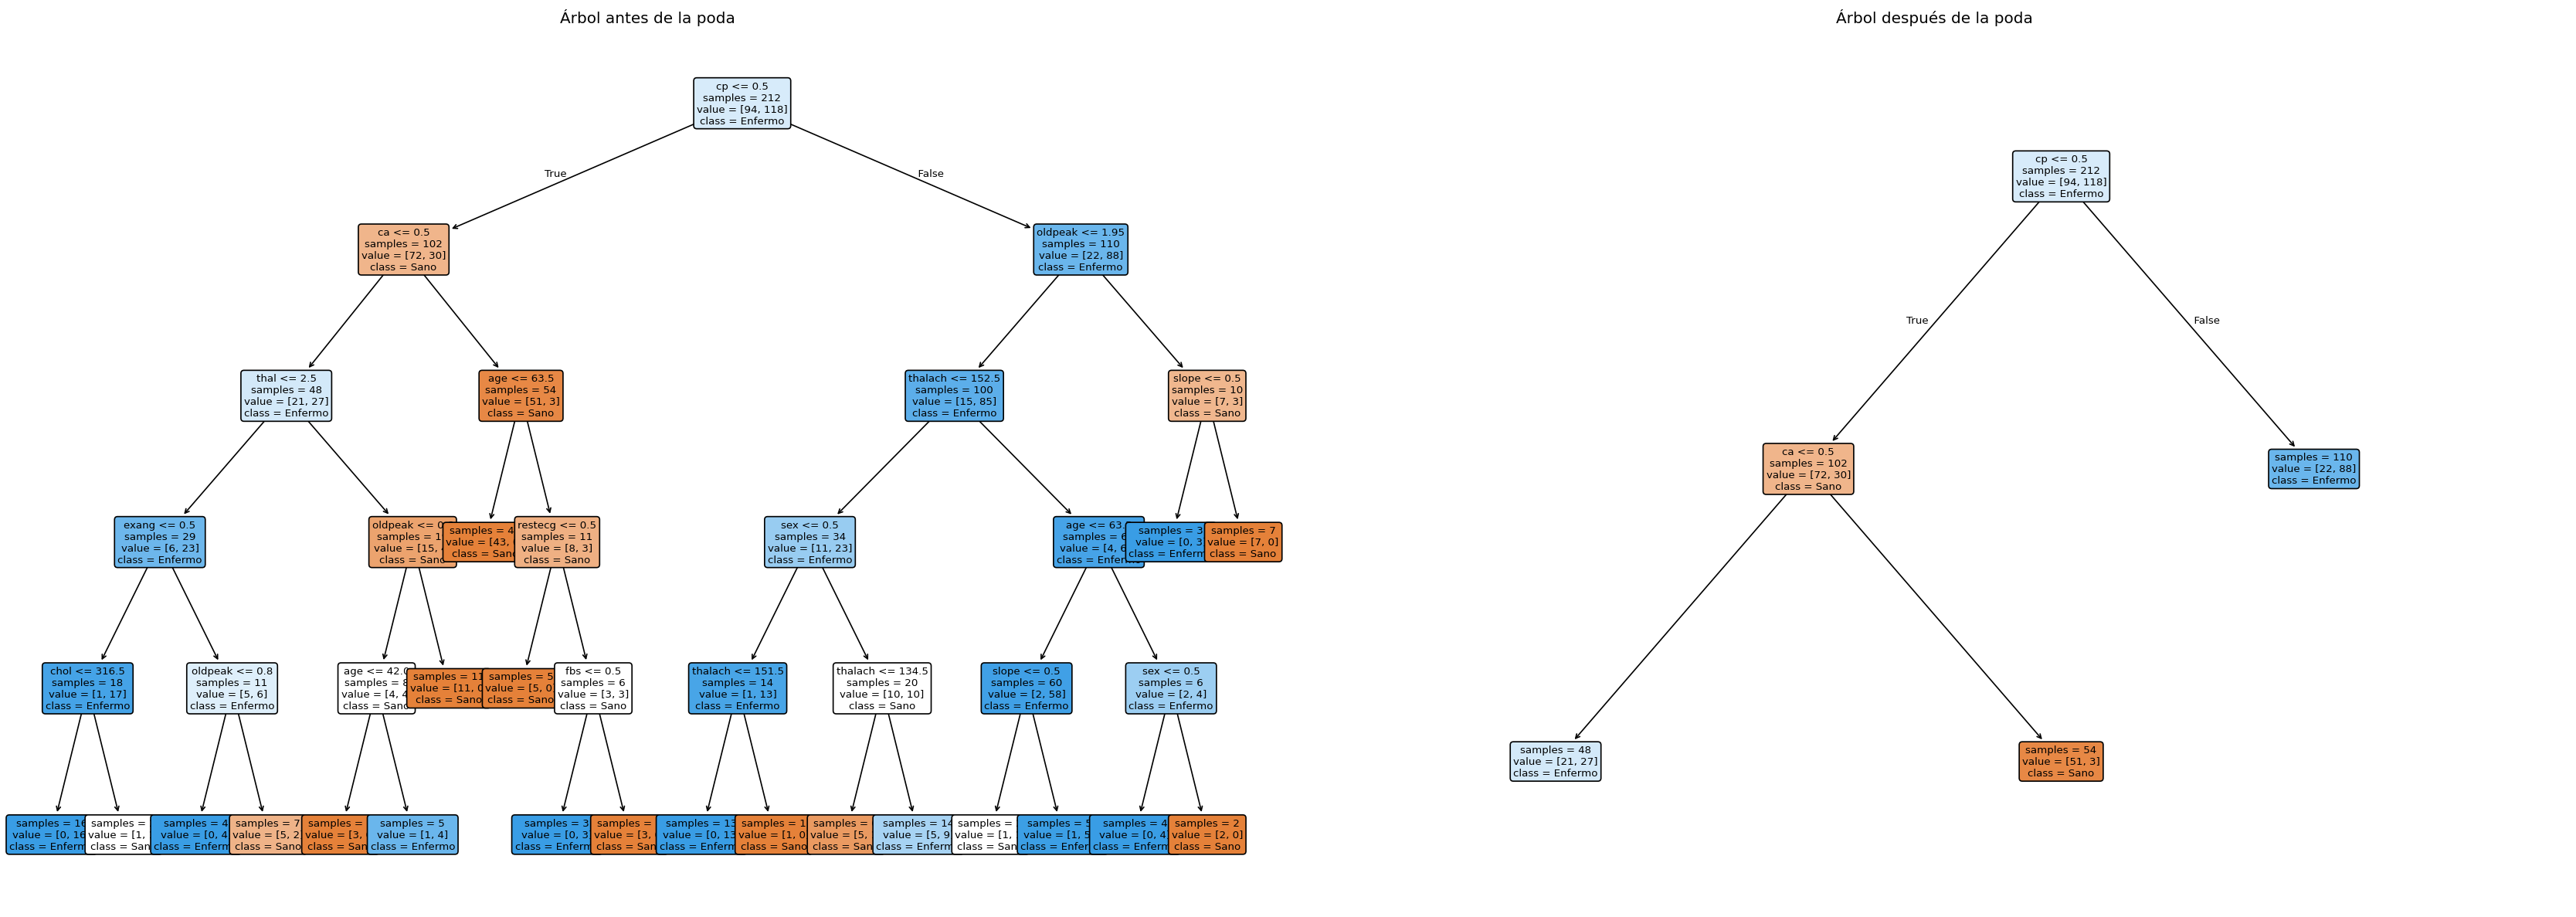

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, axes = plt.subplots(1, 2, figsize=(28, 10), dpi=120)

plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["Sano", "Enfermo"],
    filled=True,
    rounded=True,
    impurity=False,
    ax=axes[0],
    fontsize=8,
)
axes[0].set_title("Árbol antes de la poda")

plot_tree(
    pruned_tree,
    feature_names=X.columns,
    class_names=["Sano", "Enfermo"],
    filled=True,
    rounded=True,
    impurity=False,
    ax=axes[1],
    fontsize=8,
)
axes[1].set_title("Árbol después de la poda")

plt.tight_layout()
plt.show()